In [1]:
using CSV
using DataFrames
using Plots
using Colors
using Printf

In [2]:
data = """
name,input_file,seed,n,nnz,bytes,is_laplacian,is_sddm,sccs,tol,treat_as
anisotropic_poisson_grid_200000000_0,/tmp/data/anisotropic_poisson_grid_200000000_0.jld2,15698180486863115418,28652616,200006496,830134841,,,1,1.0e-8,sddm
high_contrast_poisson_grid_200000000_32,/tmp/data/high_contrast_poisson_grid_200000000_32.jld2,14482399382570843202,28652616,200006496,836967777,,,1,1.0e-8,sddm
sachdeva_star_700_350,/tmp/data/sachdeva_star_700_350.jld2,11876963183392607699,245001,171500701,18846388,,,1,1.0e-8,lap
weighted_boundary_chimera_10000000_1,/tmp/data/weighted_boundary_chimera_10000000_1.jld2,5334426756079444067,9953703,54191549,409504887,,,5125,1.0e-8,sddm
weighted_chimera_10000000_1,/tmp/data/weighted_chimera_10000000_1.jld2,13390085866912505236,10000000,54649712,412341206,,,1,1.0e-8,lap
McRae/ecology2,/tmp/data/McRae/ecology2.jld2,13331484003257118862,999999,4995991,24128707,,,1,1.0e-8,sddm
McRae/ecology1,/tmp/data/McRae/ecology1.jld2,16374742497083239433,1000000,4996000,24127739,,,1,1.0e-8,lap
"""


# Read the CSV data from the in-memory string
df0 = CSV.read(IOBuffer(data), DataFrame)


# Display the resulting DataFrame
println(df0)


7×11 DataFrame
 Row │ name                               input_file                         seed        n         nnz        bytes      is_laplacian  is_sddm  sccs   tol      treat_as 
     │ String                             String                             Float64     Int64     Int64      Int64      Missing       Missing  Int64  Float64  String7  
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ anisotropic_poisson_grid_2000000…  /tmp/data/anisotropic_poisson_gr…  1.56982e19  28652616  200006496  830134841       missing  missing      1   1.0e-8  sddm
   2 │ high_contrast_poisson_grid_20000…  /tmp/data/high_contrast_poisson_…  1.44824e19  28652616  200006496  836967777       missing  missing      1   1.0e-8  sddm
   3 │ sachdeva_star_700_350              /tmp/data/sachdeva_star_700_350.…  1.1877e19     245001  171500701   18846388       missing  missing   

In [4]:
data = """
name,status,k_param,factorisation_time_s,nnz_lo,nnz_hi,solution_time_s,pcg_iters,relative_error
sachdeva_star_700_350,solved,1,142.697284,85872500,85872500,1.992478,1,2.8308235056082117e-13
sachdeva_star_700_350,solved,2,143.458309,85872500,85872500,1.951813,1,2.8308235056082117e-13
sachdeva_star_700_350,solved,3,143.575852,85872500,85872500,1.968659,1,2.8308235056082117e-13
sachdeva_star_700_350,solved,4,144.106494,85872500,85872500,1.958897,1,2.8308235056082117e-13
weighted_boundary_chimera_10000000_1,solved,1,95.433169,61539879,61539879,604.752528,133,8.495717436016712e-9
weighted_boundary_chimera_10000000_1,solved,2,227.017731,113383056,113383056,541.757309,83,8.96180126516271e-9
weighted_boundary_chimera_10000000_1,solved,3,633.517851,208055930,208055930,615.519123,66,9.832873138549388e-9
weighted_boundary_chimera_10000000_1,solved,4,1955.347071,373979449,373979449,721.913263,48,9.571148080745356e-9
weighted_chimera_10000000_1,solved,1,95.566794,62174860,62174860,877.886321,171,4.4219559295345556e-8
weighted_chimera_10000000_1,solved,2,231.810621,114823463,114823463,1357.346843,192,3.553624341352973e-8
weighted_chimera_10000000_1,solved,3,612.946781,211104362,211104362,1997.105265,200,1.4172851185339062e-8
weighted_chimera_10000000_1,solved,4,2029.592371,379997514,379997514,3054.188414,191,1.415112812823452e-8
anisotropic_poisson_grid_200000000_0,solved,1,56.291965,199726506,199726506,524.038918,125,9.54113932730775e-9
anisotropic_poisson_grid_200000000_0,solved,2,87.804221,341588716,341588716,582.813892,99,9.680231964168813e-9
anisotropic_poisson_grid_200000000_0,solved,3,179.806316,624754071,624754071,566.239103,70,9.95388237691913e-9
anisotropic_poisson_grid_200000000_0,solved,4,311.464598,1019920306,1019920306,580.462606,54,9.535295281346532e-9
high_contrast_poisson_grid_200000000_32,solved,1,62.593446,199726506,199726506,854.009206,190,1.7207813483854688e-8
high_contrast_poisson_grid_200000000_32,solved,2,101.405605,341588716,341588716,1028.828502,171,8.634517739405257e-9
high_contrast_poisson_grid_200000000_32,solved,3,206.207737,624754071,624754071,1043.549682,128,9.194500511552302e-9
high_contrast_poisson_grid_200000000_32,solved,4,361.28619,1019920306,1019920306,1080.071109,99,9.795838151810155e-9
McRae/ecology2,solved,1,1.155917,3995993,3995993,16.878266,200,4.17481518346197e-8
McRae/ecology2,solved,2,1.513937,4992991,4992991,18.807988,187,2.988018156741727e-8
McRae/ecology2,solved,3,2.083955,6985986,6985986,23.350632,200,1.1943915811464105e-8
McRae/ecology2,solved,4,2.638145,8976982,8976982,22.286845,157,9.445352520264857e-9
McRae/ecology1,solved,1,1.140832,3995998,3995998,17.295737,175,3.2438568105345797e-5
McRae/ecology1,solved,2,1.526925,4993000,4993000,18.947924,187,3.084271356303493e-5
McRae/ecology1,solved,3,2.06534,6986004,6986004,23.158541,134,3.089961556978005e-5
McRae/ecology1,solved,4,2.606305,8977010,8977010,27.133891,105,3.084225831456567e-5
"""

# Read the CSV data from the in-memory string
df1 = CSV.read(IOBuffer(data), DataFrame)

# Add a new column "method" with the constant value "ilu(k)" for each row
df1[!, :method] = fill("ILU(k)", nrow(df1))

# Display the resulting DataFrame
println(df1)

28×10 DataFrame
 Row │ name                               status   k_param  factorisation_time_s  nnz_lo      nnz_hi      solution_time_s  pcg_iters  relative_error  method 
     │ String                             String7  Int64    Float64               Int64       Int64       Float64          Int64      Float64         String 
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350              solved         1             142.697      85872500    85872500          1.99248          1     2.83082e-13  ILU(k)
   2 │ sachdeva_star_700_350              solved         2             143.458      85872500    85872500          1.95181          1     2.83082e-13  ILU(k)
   3 │ sachdeva_star_700_350              solved         3             143.576      85872500    85872500          1.96866          1     2.83082e-13  ILU(k)
   4 │ sachdeva_star_700_350           

In [5]:
data = """
name,status,k_param,factorisation_time_s,nnz_lo,nnz_hi,solution_time_s,pcg_iters,relative_error
sachdeva_star_700_350,solved,1,48.54916501045227,85875711,85875711,323.7032699584961,416,9.51747543192303e-9
sachdeva_star_700_350,solved,2,84.32447290420532,85881229,85881229,35.305160999298096,46,7.614393454743692e-9
anisotropic_poisson_grid_200000000_0,solved,1,86.74100089073181,257836193,257836193,227.5739710330963,40,7.316452231679001e-9
anisotropic_poisson_grid_200000000_0,solved,2,175.91168308258057,347217850,347217850,228.07864713668823,26,5.750001059283358e-9
high_contrast_poisson_grid_200000000_32,solved,1,89.13559794425964,268471798,268471798,342.4774339199066,59,8.392473774243765e-9
high_contrast_poisson_grid_200000000_32,solved,2,182.49084210395813,371370700,371370700,395.121630191803,44,9.672145143074953e-9
weighted_boundary_chimera_10000000_1,solved,1,39.742156982421875,69956110,69956110,128.24494290351868,37,6.66998661460035e-9
weighted_boundary_chimera_10000000_1,solved,2,65.17965888977051,92663274,92663274,111.7504448890686,26,5.906417979326677e-9
weighted_chimera_10000000_1,solved,1,45.11845111846924,74273403,74273403,97.33402299880981,26,8.476494563547517e-9
weighted_chimera_10000000_1,solved,2,73.27236294746399,100430951,100430951,85.34627890586853,20,7.503605045100883e-9
McRae/ecology2,solved,1,1.1913738250732422,5406140,5406140,3.261389970779419,41,7.083323073643435e-9
McRae/ecology2,solved,2,2.146501064300537,6429666,6429666,2.556785821914673,25,7.1941774282262224e-9
McRae/ecology1,solved,1,1.1838629245758057,5407779,5407779,3.200061082839966,41,8.786756813883156e-9
McRae/ecology1,solved,2,2.1748909950256348,6431605,6431605,2.411324977874756,25,8.335065014412723e-9
"""

# Read the CSV data from an in-memory string
df2 = CSV.read(IOBuffer(data), DataFrame)

# Add a new column "method" with the constant value "ac(k)"
df2[!, :method] = fill("AC(k)", nrow(df2))

# Display the resulting DataFrame
println(df2)

14×10 DataFrame
 Row │ name                               status   k_param  factorisation_time_s  nnz_lo     nnz_hi     solution_time_s  pcg_iters  relative_error  method 
     │ String                             String7  Int64    Float64               Int64      Int64      Float64          Int64      Float64         String 
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350              solved         1              48.5492    85875711   85875711        323.703          416      9.51748e-9  AC(k)
   2 │ sachdeva_star_700_350              solved         2              84.3245    85881229   85881229         35.3052          46      7.61439e-9  AC(k)
   3 │ anisotropic_poisson_grid_2000000…  solved         1              86.741    257836193  257836193        227.574           40      7.31645e-9  AC(k)
   4 │ anisotropic_poisson_grid_2000000…  solved      

In [6]:
data = """
name,status,k_param,factorisation_time_s,nnz_lo,nnz_hi,solution_time_s,pcg_iters,relative_error
sachdeva_star_700_350,solved,1,39.61774921417236,85872850,85872850,14.933838844299316,19,5.4328200662587845e-9
sachdeva_star_700_350,solved,2,75.36790585517883,85872850,85872850,11.320603847503662,14,4.909839234020094e-9
anisotropic_poisson_grid_200000000_0,solved,1,169.86159300804138,789028795,789028795,306.18578004837036,45,2.992763828751514e-9
anisotropic_poisson_grid_200000000_0,solved,2,497.8188409805298,1823978884,1823978884,316.5287449359894,22,2.060242579615276e-9
weighted_boundary_chimera_10000000_1,solved,1,32.11272406578064,82186083,82186083,282.71782398223877,101,9.558701278915309e-9
weighted_boundary_chimera_10000000_1,solved,2,54.329294204711914,114763936,114763936,206.1593999862671,62,9.007880152249366e-9
weighted_chimera_10000000_1,solved,1,36.761240005493164,94151990,94151990,398.0384669303894,129,9.760065049831946e-9
weighted_chimera_10000000_1,solved,2,65.93077087402344,140875586,140875586,205.69285011291504,57,9.456349657145794e-9
high_contrast_poisson_grid_200000000_32,solved,1,170.5283658504486,836063490,836063490,673.0417749881744,105,9.946572550282474e-9
McRae/ecology2,solved,1,1.0649449825286865,9910442,9910442,4.186563968658447,43,8.192814356156623e-9
McRae/ecology2,solved,2,4.055065155029297,26174707,26174707,3.9116411209106445,18,9.378823072263592e-9
McRae/ecology1,solved,1,1.0258688926696777,9927995,9927995,3.8469719886779785,42,6.843202142549417e-9
McRae/ecology1,solved,2,4.302411794662476,26362785,26362785,3.2234280109405518,18,6.41256019142957e-9
"""

# Read the CSV data from an in-memory string
df3 = CSV.read(IOBuffer(data), DataFrame)

# Add a new column "method" with the constant value "ac(k)"
df3[!, :method] = fill("AC(k,given)", nrow(df3))

# Display the resulting DataFrame
println(df3)

13×10 DataFrame
 Row │ name                               status   k_param  factorisation_time_s  nnz_lo      nnz_hi      solution_time_s  pcg_iters  relative_error  method      
     │ String                             String7  Int64    Float64               Int64       Int64       Float64          Int64      Float64         String      
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350              solved         1              39.6177     85872850    85872850         14.9338          19      5.43282e-9  AC(k,given)
   2 │ sachdeva_star_700_350              solved         2              75.3679     85872850    85872850         11.3206          14      4.90984e-9  AC(k,given)
   3 │ anisotropic_poisson_grid_2000000…  solved         1             169.862     789028795   789028795        306.186           45      2.99276e-9  AC(k,given)
   4 │ an

In [7]:
data = """
name,t_param,status,k_param,factorisation_time_s,nnz_lo,nnz_hi,solution_time_s,pcg_iters,relative_error
sachdeva_star_700_350,1e-5,solved,8,14.461639881134033,2192400,2192400,2.8600759506225586,8,5.165620848092983e-10
sachdeva_star_700_350,1e-5,solved,16,16.817456007003784,4117400,4117400,3.314181089401245,9,6.357530348510801e-10
anisotropic_poisson_grid_200000000_0,1e-5,solved,8,30.748531818389893,257404141,257867093,197.11954808235168,64,9.998183892882057e-9
anisotropic_poisson_grid_200000000_0,1e-5,solved,16,60.89577794075012,485875030,487057970,391.39081501960754,86,9.948404106352384e-9
weighted_boundary_chimera_10000000_1,1e-5,solved,8,146.07950901985168,49287049,61811796,3280.9297349452972,1000,0.0001534183422139619
weighted_boundary_chimera_10000000_1,1e-5,solved,16,315.7439429759979,76830174,97872343,4277.007590055466,1000,5.346724025681804e-6
weighted_chimera_10000000_1,1e-5,solved,8,212.13693404197693,50093565,63408771,3468.6083040237427,1000,8.666212114182947e-5
weighted_chimera_10000000_1,1e-5,solved,16,451.37084317207336,79546593,101426708,4348.187988042831,1000,6.504280135249443e-5
high_contrast_poisson_grid_200000000_32,1e-5,OOM,8,inf,0,0,inf,1000,inf
high_contrast_poisson_grid_200000000_32,1e-5,OOM,16,inf,0,0,inf,1000,inf

sachdeva_star_700_350,1e-6,solved,8,15.594445943832397,2192400,2192400,2.875967025756836,8,5.165620848092983e-10
sachdeva_star_700_350,1e-6,solved,16,18.076181888580322,4117400,4117400,3.3677608966827393,9,6.357530348510801e-10
anisotropic_poisson_grid_200000000_0,1e-6,solved,8,39.025094985961914,257404141,257868932,198.74042916297913,64,9.998184008185338e-9
anisotropic_poisson_grid_200000000_0,1e-6,solved,16,70.82803511619568,485875979,487072644,377.8475978374481,86,9.945619498130972e-9
weighted_boundary_chimera_10000000_1,1e-6,solved,8,218.21533012390137,49584278,62572500,3332.328181028366,1000,8.173332728906614e-5
weighted_boundary_chimera_10000000_1,1e-6,solved,16,409.9405870437622,78358181,99745149,4285.999772787094,1000,5.7538729446135705e-6
weighted_chimera_10000000_1,1e-6,solved,8,226.99452805519104,50135029,63638506,3021.5384180545807,1000,8.672877761551041e-5
weighted_chimera_10000000_1,1e-6,solved,16,628.5526068210602,80256367,102135515,4549.215502977371,1000,6.504191120303001e-5
high_contrast_poisson_grid_200000000_32,1e-6,OOM,8,inf,0,0,inf,1000,inf
high_contrast_poisson_grid_200000000_32,1e-6,OOM,16,inf,0,0,inf,1000,inf

sachdeva_star_700_350,1e-7,solved,8,14.730944871902466,2192400,2192400,2.973177909851074,8,5.165620848092983e-10
sachdeva_star_700_350,1e-7,solved,16,17.087463855743408,4117400,4117400,3.574007987976074,9,6.357530348510801e-10
anisotropic_poisson_grid_200000000_0,1e-7,solved,8,44.64668917655945,257404141,257869542,201.7381579875946,64,9.998184010655058e-9
anisotropic_poisson_grid_200000000_0,1e-7,solved,16,81.95207715034485,485875981,487073880,394.08124899864197,86,9.94561856888361e-9
weighted_boundary_chimera_10000000_1,1e-7,solved,8,270.55467796325684,49709261,62887942,3213.3697249889374,1000,0.0001460371693434765
weighted_boundary_chimera_10000000_1,1e-7,solved,16,724.7761080265045,79144545,100693529,4144.404582023621,1000,7.1176538679933334e-6
weighted_chimera_10000000_1,1e-7,solved,8,308.1685070991516,50146273,63734677,2983.0177879333496,1000,8.673038501058222e-5
weighted_chimera_10000000_1,1e-7,solved,16,1146.3494980335236,80580902,102401074,3729.3378159999847,1000,6.504150010975678e-5
high_contrast_poisson_grid_200000000_32,1e-7,OOM,8,inf,0,0,inf,1000,inf
high_contrast_poisson_grid_200000000_32,1e-7,OOM,16,inf,0,0,inf,1000,inf

sachdeva_star_700_350,1e-8,solved,8,15.290303945541382,2192400,2192400,2.9039671421051025,8,5.165620848092983e-10
sachdeva_star_700_350,1e-8,solved,16,17.715941190719604,4117400,4117400,3.408892869949341,9,6.357530348510801e-10
anisotropic_poisson_grid_200000000_0,1e-8,solved,8,47.86510109901428,257497166,257870766,167.97713994979858,64,9.998184012482035e-9
anisotropic_poisson_grid_200000000_0,1e-8,solved,16,91.66739797592163,485969919,487080589,314.9977889060974,86,9.945618574669606e-9
weighted_boundary_chimera_10000000_1,1e-8,solved,8,341.5929319858551,49778195,63013914,3430.616446018219,1000,0.00014621955554855974
weighted_boundary_chimera_10000000_1,1e-8,solved,16,915.6562881469727,79562263,101108028,4145.425140142441,1000,7.016151346509195e-6
weighted_chimera_10000000_1,1e-8,solved,8,473.2396330833435,50149291,63774380,3270.4650201797485,1000,8.673046401784187e-5
weighted_chimera_10000000_1,1e-8,solved,16,2119.970090150833,80728992,102492255,4165.7378759384155,1000,6.504150262829755e-5
high_contrast_poisson_grid_200000000_32,1e-8,OOM,8,inf,0,0,inf,1000,inf
high_contrast_poisson_grid_200000000_32,1e-8,OOM,16,inf,0,0,inf,1000,inf

sachdeva_star_700_350,0,solved,8,14.726180076599121,2192400,2192400,2.9685709476470947,8,5.165620848092983e-10
sachdeva_star_700_350,0,solved,16,17.11973214149475,4117400,4117400,3.4701340198516846,9,6.357530348510801e-10
anisotropic_poisson_grid_200000000_0,0,solved,8,1905.3426368236542,257865004,257873499,165.7661271095276,64,9.998184012443454e-9
anisotropic_poisson_grid_200000000_0,0,solved,16,43223.07787299156,487057977,487094287,311.7710301876068,86,9.945618574558281e-9
weighted_boundary_chimera_10000000_1,0,solved,8,801.730062007904,49862127,63221559,3284.908674955368,1000,0.00028583150044830146
weighted_boundary_chimera_10000000_1,0,solved,16,86838.63516497612,80142487,101560961,4181.10245013237,1000,6.79146358128135e-6
weighted_chimera_10000000_1,0,solved,8,20429.152235031128,50150563,63814024,2969.7090280056,1000,8.673046143645341e-5
weighted_chimera_10000000_1,0,timeout,16,inf,0,0,inf,1000,inf
high_contrast_poisson_grid_200000000_32,0,OOM,8,inf,0,0,inf,1000,inf
high_contrast_poisson_grid_200000000_32,0,OOM,16,inf,0,0,inf,1000,inf
"""

# Read the CSV data from an in-memory string
df4 = CSV.read(IOBuffer(data), DataFrame)

# Add a new column "method" with the constant value "ac(k)"
df4[!, :method] = fill("ILUT", nrow(df4))

# Display the resulting DataFrame
println(df4)

50×11 DataFrame
 Row │ name                               t_param  status   k_param  factorisation_time_s  nnz_lo     nnz_hi     solution_time_s  pcg_iters  relative_error  method 
     │ String                             Float64  String7  Int64    Float64               Int64      Int64      Float64          Int64      Float64         String 
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350               1.0e-5  solved         8               14.4616    2192400    2192400          2.86008          8     5.16562e-10  ILUT
   2 │ sachdeva_star_700_350               1.0e-5  solved        16               16.8175    4117400    4117400          3.31418          9     6.35753e-10  ILUT
   3 │ anisotropic_poisson_grid_2000000…   1.0e-5  solved         8               30.7485  257404141  257867093        197.12            64     9.99818e-9   ILUT
   

In [10]:
Tin = df0
Tiluk = df1
Tack = df2
TackGiven = df3
Tilut = df4 


noParamtData = vcat(Tiluk, Tack, TackGiven)
noParamtData[!, :t_param] = fill("N/A", nrow(noParamtData))


# 1. Concatenate Tiluk and Tack vertically, then join with Tin on "name"
T = innerjoin(Tin, vcat(noParamtData, Tilut), on = :name)

# 2. Print a summary of the joined DataFrame (rough equivalent to T.glimpse())
println("DataFrame Summary:")
describe(T)
println()

# 3. Select only the desired columns
T = select(T, [:name, :n, :nnz, :method, :k_param, :t_param, :status, :nnz_lo, :nnz_hi, :pcg_iters, :relative_error])

# 4. Create a new column "fillin" computed as nnz_lo divided by nnz (elementwise)
T.fillin = T.nnz_lo ./ T.nnz

# 5. Sort the DataFrame by "name", "method", and "k_param"
T = sort(T, [:name, :method, :k_param])

# 6.  relabel ILUT rows so we get two separate methods
transform!(
    T,
    [:method, :k_param] => ByRow() do m, k
        lowercase(m) == "ilut" ? "ILUT(k=$(k),t)" : m
    end => :method)

# 7. Display the full DataFrame (all rows and columns)
show(T, allcols=true, allrows=true)

DataFrame Summary:

105×12 DataFrame
 Row │ name                               n         nnz        method        k_param  t_param  status   nnz_lo      nnz_hi      pcg_iters  relative_error  fillin    
     │ String                             Int64     Int64      String        Int64    Any      String7  Int64       Int64       Int64      Float64         Float64   
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ McRae/ecology1                      1000000    4996000  AC(k)               1  N/A      solved      5407779     5407779         41     8.78676e-9   1.08242
   2 │ McRae/ecology1                      1000000    4996000  AC(k)               2  N/A      solved      6431605     6431605         25     8.33507e-9   1.28735
   3 │ McRae/ecology1                      1000000    4996000  AC(k,given)         1  N/A      solved      9927995     9927995         42  

  62 │ sachdeva_star_700_350                245001  171500701  ILUT(k=8,t)         8  1.0e-7   solved      2192400     2192400          8     5.16562e-10  0.0127836
  63 │ sachdeva_star_700_350                245001  171500701  ILUT(k=8,t)         8  1.0e-8   solved      2192400     2192400          8     5.16562e-10  0.0127836
  64 │ sachdeva_star_700_350                245001  171500701  ILUT(k=8,t)         8  0.0      solved      2192400     2192400          8     5.16562e-10  0.0127836
  65 │ sachdeva_star_700_350                245001  171500701  ILUT(k=16,t)       16  1.0e-5   solved      4117400     4117400          9     6.35753e-10  0.0240081
  66 │ sachdeva_star_700_350                245001  171500701  ILUT(k=16,t)       16  1.0e-6   solved      4117400     4117400          9     6.35753e-10  0.0240081
  67 │ sachdeva_star_700_350                245001  171500701  ILUT(k=16,t)       16  1.0e-7   solved      4117400     4117400          9     6.35753e-10  0.0240081
  68 │ sac

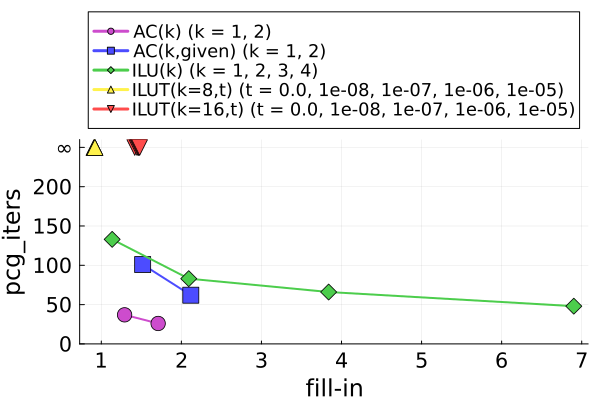

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_wb.png"

In [15]:
# ------------------------------------------------------------------
# 0. data you want to plot
Twb = filter(row -> row.name == "weighted_boundary_chimera_10000000_1", T)

# ------------------------------------------------------------------
# 1. pick a shape for every distinct method ------------------------
all_methods = unique(Twb.method)                     # ["ac(k)", "ILUT(k=8,t)", …]
shapes_pool = [:circle, :square, :diamond, :utriangle, :dtriangle,
               :rtriangle, :ltriangle, :pentagon, :hexagon, :star5]

method_shape = Dict(m => shapes_pool[1 + mod(i-1, length(shapes_pool))]
                    for (i, m) in enumerate(all_methods))
# e.g.  "ac(k)" => :circle,  "ILUT(k=8,t)" => :square, …

# ------------------------------------------------------------------
# 2. constants for the “∞” row
YMAX  = 200
INF_Y = 250
PAD_Y = 260                             # top of the frame

yticks_pos   = vcat(0:50:YMAX, INF_Y)
yticks_label = vcat(string.(0:50:YMAX), "∞")

# ------------------------------------------------------------------
# 3. plotting setup
method_groups = groupby(Twb, :method)
cols          = palette(:lightrainbow, length(method_groups))

plt = plot(xlabel  = "fill-in",
           ylabel  = "pcg_iters",
           xguidefont = font(16),
           yguidefont = font(16),
           legendfontsize = 12,
           tickfont = font(14),
           ylims   = (0, PAD_Y),
           yticks  = (yticks_pos, yticks_label),
           legend  = :outertop, orientation = :vertical)

fmt_t(t) = t == 0.0 ? "0.0" : @sprintf("%.0e", t)   # legend helper

# ------------------------------------------------------------------
# 4. one series per method
for (i, subdf) in enumerate(method_groups)

    sort!(subdf, :fillin)                # l-to-r line

    # -------- legend entry ----------------------------------------
    if startswith(subdf.method[1], "ILUT")
        ts    = sort(unique(subdf.t_param))
        label = "ILUT(k=$(subdf.k_param[1]),t) (t = $(join(fmt_t.(ts), ", ")))"
    else
        ks    = sort(unique(subdf.k_param))
        label = "$(subdf.method[1]) (k = $(join(string.(ks), ", ")))"
    end

    # -------- y-data with “∞” mapping -----------------------------
    yvals = map(p -> p > YMAX ? INF_Y : p, subdf.pcg_iters)

    plot!(plt,
          subdf.fillin,
          yvals;
          marker     = (method_shape[subdf.method[1]], 8),   # <- shape from dict
          color      = cols[i],
          linewidth  = 2,
          linestyle  = :solid,
          label      = label)
end

display(plt)
savefig(plt, "scatter_wb.png")


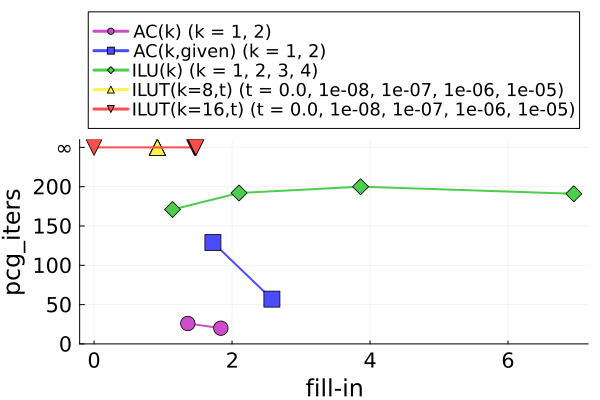

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_wc.png"

In [17]:
# ------------------------------------------------------------------
# 0. data you want to plot
Twb = filter(row -> row.name == "weighted_chimera_10000000_1", T)

# ------------------------------------------------------------------
# 1. pick a shape for every distinct method ------------------------
all_methods = unique(Twb.method)                     # ["ac(k)", "ILUT(k=8,t)", …]
shapes_pool = [:circle, :square, :diamond, :utriangle, :dtriangle,
               :rtriangle, :ltriangle, :pentagon, :hexagon, :star5]

method_shape = Dict(m => shapes_pool[1 + mod(i-1, length(shapes_pool))]
                    for (i, m) in enumerate(all_methods))
# e.g.  "ac(k)" => :circle,  "ILUT(k=8,t)" => :square, …

# ------------------------------------------------------------------
# 2. constants for the “∞” row
YMAX  = 200
INF_Y = 250
PAD_Y = 260                             # top of the frame

yticks_pos   = vcat(0:50:YMAX, INF_Y)
yticks_label = vcat(string.(0:50:YMAX), "∞")

# ------------------------------------------------------------------
# 3. plotting setup
method_groups = groupby(Twb, :method)
cols          = palette(:lightrainbow, length(method_groups))

plt = plot(xlabel  = "fill-in",
           ylabel  = "pcg_iters",
           xguidefont = font(16),
           yguidefont = font(16),
           legendfontsize = 12,
           tickfont = font(14),
           ylims   = (0, PAD_Y),
           yticks  = (yticks_pos, yticks_label),
           legend  = :outertop, orientation = :vertical)

fmt_t(t) = t == 0.0 ? "0.0" : @sprintf("%.0e", t)   # legend helper

# ------------------------------------------------------------------
# 4. one series per method
for (i, subdf) in enumerate(method_groups)

    sort!(subdf, :fillin)                # l-to-r line

    # -------- legend entry ----------------------------------------
    if startswith(subdf.method[1], "ILUT")
        ts    = sort(unique(subdf.t_param))
        label = "ILUT(k=$(subdf.k_param[1]),t) (t = $(join(fmt_t.(ts), ", ")))"
    else
        ks    = sort(unique(subdf.k_param))
        label = "$(subdf.method[1]) (k = $(join(string.(ks), ", ")))"
    end

    # -------- y-data with “∞” mapping -----------------------------
    yvals = map(p -> p > YMAX ? INF_Y : p, subdf.pcg_iters)

    plot!(plt,
          subdf.fillin,
          yvals;
          marker     = (method_shape[subdf.method[1]], 8),   # <- shape from dict
          color      = cols[i],
          linewidth  = 2,
          linestyle  = :solid,
          label      = label)
end

display(plt)
savefig(plt, "scatter_wc.png")


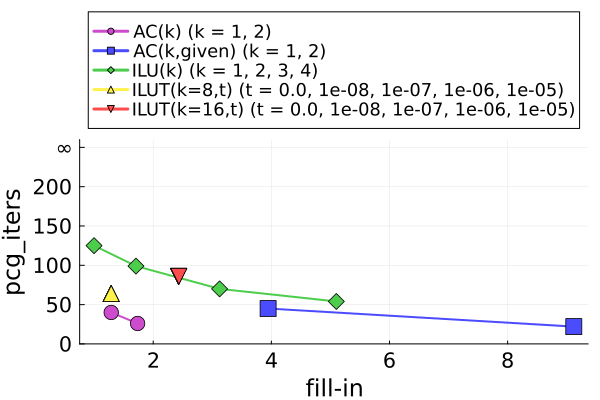

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_an.png"

In [19]:
# ------------------------------------------------------------------
# 0. data you want to plot
Twb = filter(row -> row.name == "anisotropic_poisson_grid_200000000_0", T)

# ------------------------------------------------------------------
# 1. pick a shape for every distinct method ------------------------
all_methods = unique(Twb.method)                     # ["ac(k)", "ILUT(k=8,t)", …]
shapes_pool = [:circle, :square, :diamond, :utriangle, :dtriangle,
               :rtriangle, :ltriangle, :pentagon, :hexagon, :star5]

method_shape = Dict(m => shapes_pool[1 + mod(i-1, length(shapes_pool))]
                    for (i, m) in enumerate(all_methods))
# e.g.  "ac(k)" => :circle,  "ILUT(k=8,t)" => :square, …

# ------------------------------------------------------------------
# 2. constants for the “∞” row
YMAX  = 200
INF_Y = 250
PAD_Y = 260                             # top of the frame

yticks_pos   = vcat(0:50:YMAX, INF_Y)
yticks_label = vcat(string.(0:50:YMAX), "∞")

# ------------------------------------------------------------------
# 3. plotting setup
method_groups = groupby(Twb, :method)
cols          = palette(:lightrainbow, length(method_groups))

plt = plot(xlabel  = "fill-in",
           ylabel  = "pcg_iters",
           xguidefont = font(16),
           yguidefont = font(16),
           legendfontsize = 12,
           tickfont = font(14),
           ylims   = (0, PAD_Y),
           yticks  = (yticks_pos, yticks_label),
           legend  = :outertop, orientation = :vertical)

fmt_t(t) = t == 0.0 ? "0.0" : @sprintf("%.0e", t)   # legend helper

# ------------------------------------------------------------------
# 4. one series per method
for (i, subdf) in enumerate(method_groups)

    sort!(subdf, :fillin)                # l-to-r line

    # -------- legend entry ----------------------------------------
    if startswith(subdf.method[1], "ILUT")
        ts    = sort(unique(subdf.t_param))
        label = "ILUT(k=$(subdf.k_param[1]),t) (t = $(join(fmt_t.(ts), ", ")))"
    else
        ks    = sort(unique(subdf.k_param))
        label = "$(subdf.method[1]) (k = $(join(string.(ks), ", ")))"
    end

    # -------- y-data with “∞” mapping -----------------------------
    yvals = map(p -> p > YMAX ? INF_Y : p, subdf.pcg_iters)

    plot!(plt,
          subdf.fillin,
          yvals;
          marker     = (method_shape[subdf.method[1]], 8),   # <- shape from dict
          color      = cols[i],
          linewidth  = 2,
          linestyle  = :solid,
          label      = label)
end

display(plt)
savefig(plt, "scatter_an.png")


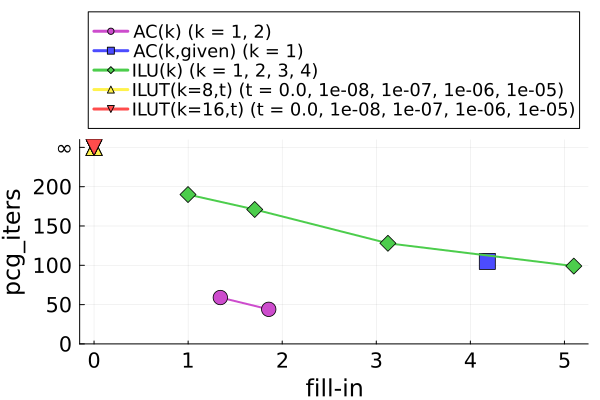

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_hc.png"

In [21]:
# ------------------------------------------------------------------
# 0. data you want to plot
Twb = filter(row -> row.name == "high_contrast_poisson_grid_200000000_32", T)

# ------------------------------------------------------------------
# 1. pick a shape for every distinct method ------------------------
all_methods = unique(Twb.method)                     # ["ac(k)", "ILUT(k=8,t)", …]
shapes_pool = [:circle, :square, :diamond, :utriangle, :dtriangle,
               :rtriangle, :ltriangle, :pentagon, :hexagon, :star5]

method_shape = Dict(m => shapes_pool[1 + mod(i-1, length(shapes_pool))]
                    for (i, m) in enumerate(all_methods))
# e.g.  "ac(k)" => :circle,  "ILUT(k=8,t)" => :square, …

# ------------------------------------------------------------------
# 2. constants for the “∞” row
YMAX  = 200
INF_Y = 250
PAD_Y = 260                             # top of the frame

yticks_pos   = vcat(0:50:YMAX, INF_Y)
yticks_label = vcat(string.(0:50:YMAX), "∞")

# ------------------------------------------------------------------
# 3. plotting setup
method_groups = groupby(Twb, :method)
cols          = palette(:lightrainbow, length(method_groups))

plt = plot(xlabel  = "fill-in",
           ylabel  = "pcg_iters",
           xguidefont = font(16),
           yguidefont = font(16),
           legendfontsize = 12,
           tickfont = font(14),
           ylims   = (0, PAD_Y),
           yticks  = (yticks_pos, yticks_label),
           legend  = :outertop, orientation = :vertical)

fmt_t(t) = t == 0.0 ? "0.0" : @sprintf("%.0e", t)   # legend helper

# ------------------------------------------------------------------
# 4. one series per method
for (i, subdf) in enumerate(method_groups)

    sort!(subdf, :fillin)                # l-to-r line

    # -------- legend entry ----------------------------------------
    if startswith(subdf.method[1], "ILUT")
        ts    = sort(unique(subdf.t_param))
        label = "ILUT(k=$(subdf.k_param[1]),t) (t = $(join(fmt_t.(ts), ", ")))"
    else
        ks    = sort(unique(subdf.k_param))
        label = "$(subdf.method[1]) (k = $(join(string.(ks), ", ")))"
    end

    # -------- y-data with “∞” mapping -----------------------------
    yvals = map(p -> p > YMAX ? INF_Y : p, subdf.pcg_iters)

    plot!(plt,
          subdf.fillin,
          yvals;
          marker     = (method_shape[subdf.method[1]], 8),   # <- shape from dict
          color      = cols[i],
          linewidth  = 2,
          linestyle  = :solid,
          label      = label)
end

display(plt)
savefig(plt, "scatter_hc.png")


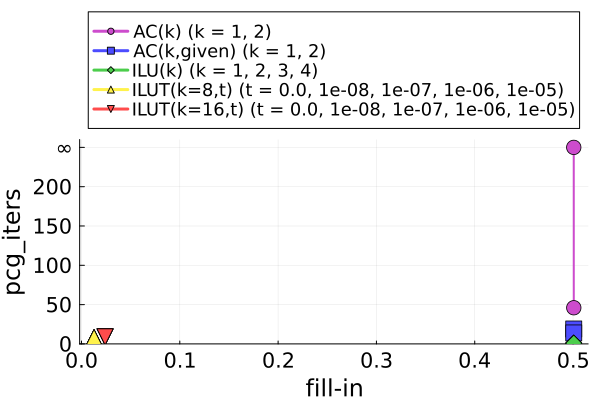

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_hc.png"

In [22]:
# ------------------------------------------------------------------
# 0. data you want to plot
Twb = filter(row -> row.name == "sachdeva_star_700_350", T)

# ------------------------------------------------------------------
# 1. pick a shape for every distinct method ------------------------
all_methods = unique(Twb.method)                     # ["ac(k)", "ILUT(k=8,t)", …]
shapes_pool = [:circle, :square, :diamond, :utriangle, :dtriangle,
               :rtriangle, :ltriangle, :pentagon, :hexagon, :star5]

method_shape = Dict(m => shapes_pool[1 + mod(i-1, length(shapes_pool))]
                    for (i, m) in enumerate(all_methods))
# e.g.  "ac(k)" => :circle,  "ILUT(k=8,t)" => :square, …

# ------------------------------------------------------------------
# 2. constants for the “∞” row
YMAX  = 200
INF_Y = 250
PAD_Y = 260                             # top of the frame

yticks_pos   = vcat(0:50:YMAX, INF_Y)
yticks_label = vcat(string.(0:50:YMAX), "∞")

# ------------------------------------------------------------------
# 3. plotting setup
method_groups = groupby(Twb, :method)
cols          = palette(:lightrainbow, length(method_groups))

plt = plot(xlabel  = "fill-in",
           ylabel  = "pcg_iters",
           xguidefont = font(16),
           yguidefont = font(16),
           legendfontsize = 12,
           tickfont = font(14),
           ylims   = (0, PAD_Y),
           yticks  = (yticks_pos, yticks_label),
           legend  = :outertop, orientation = :vertical)

fmt_t(t) = t == 0.0 ? "0.0" : @sprintf("%.0e", t)   # legend helper

# ------------------------------------------------------------------
# 4. one series per method
for (i, subdf) in enumerate(method_groups)

    sort!(subdf, :fillin)                # l-to-r line

    # -------- legend entry ----------------------------------------
    if startswith(subdf.method[1], "ILUT")
        ts    = sort(unique(subdf.t_param))
        label = "ILUT(k=$(subdf.k_param[1]),t) (t = $(join(fmt_t.(ts), ", ")))"
    else
        ks    = sort(unique(subdf.k_param))
        label = "$(subdf.method[1]) (k = $(join(string.(ks), ", ")))"
    end

    # -------- y-data with “∞” mapping -----------------------------
    yvals = map(p -> p > YMAX ? INF_Y : p, subdf.pcg_iters)

    plot!(plt,
          subdf.fillin,
          yvals;
          marker     = (method_shape[subdf.method[1]], 8),   # <- shape from dict
          color      = cols[i],
          linewidth  = 2,
          linestyle  = :solid,
          label      = label)
end

display(plt)
savefig(plt, "scatter_hc.png")


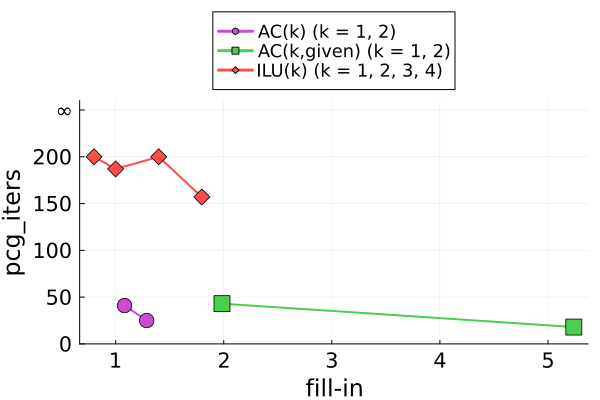

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_ec.png"

In [24]:
# ------------------------------------------------------------------
# 0. data you want to plot
Twb = filter(row -> row.name == "McRae/ecology2", T)

# ------------------------------------------------------------------
# 1. pick a shape for every distinct method ------------------------
all_methods = unique(Twb.method)                     # ["ac(k)", "ILUT(k=8,t)", …]
shapes_pool = [:circle, :square, :diamond, :utriangle, :dtriangle,
               :rtriangle, :ltriangle, :pentagon, :hexagon, :star5]

method_shape = Dict(m => shapes_pool[1 + mod(i-1, length(shapes_pool))]
                    for (i, m) in enumerate(all_methods))
# e.g.  "ac(k)" => :circle,  "ILUT(k=8,t)" => :square, …

# ------------------------------------------------------------------
# 2. constants for the “∞” row
YMAX  = 200
INF_Y = 250
PAD_Y = 260                             # top of the frame

yticks_pos   = vcat(0:50:YMAX, INF_Y)
yticks_label = vcat(string.(0:50:YMAX), "∞")

# ------------------------------------------------------------------
# 3. plotting setup
method_groups = groupby(Twb, :method)
cols          = palette(:lightrainbow, length(method_groups))

plt = plot(xlabel  = "fill-in",
           ylabel  = "pcg_iters",
           xguidefont = font(16),
           yguidefont = font(16),
           legendfontsize = 12,
           tickfont = font(14),
           ylims   = (0, PAD_Y),
           yticks  = (yticks_pos, yticks_label),
           legend  = :outertop, orientation = :vertical)

fmt_t(t) = t == 0.0 ? "0.0" : @sprintf("%.0e", t)   # legend helper

# ------------------------------------------------------------------
# 4. one series per method
for (i, subdf) in enumerate(method_groups)

    sort!(subdf, :fillin)                # l-to-r line

    # -------- legend entry ----------------------------------------
    if startswith(subdf.method[1], "ILUT")
        ts    = sort(unique(subdf.t_param))
        label = "ILUT(k=$(subdf.k_param[1]),t) (t = $(join(fmt_t.(ts), ", ")))"
    else
        ks    = sort(unique(subdf.k_param))
        label = "$(subdf.method[1]) (k = $(join(string.(ks), ", ")))"
    end

    # -------- y-data with “∞” mapping -----------------------------
    yvals = map(p -> p > YMAX ? INF_Y : p, subdf.pcg_iters)

    plot!(plt,
          subdf.fillin,
          yvals;
          marker     = (method_shape[subdf.method[1]], 8),   # <- shape from dict
          color      = cols[i],
          linewidth  = 2,
          linestyle  = :solid,
          label      = label)
end

display(plt)
savefig(plt, "scatter_ec.png")
